
# Approche 2.1: Tracking d'objet principal et organisation spatiale sur images


In [2]:
import numpy as np
import os
import gdown
import supervision as sv
from tqdm.notebook import tqdm
import cv2
#Si vous exécutez le code sur colab c'est une alternative pour imshow de cv2 qui n'y fonctionne pas
from google.colab.patches import cv2_imshow

In [3]:
HOME = os.getcwd()
print(HOME)

/content


In [4]:
VIDEO_DIR_PATH = f"{HOME}/videos"
IMAGE_DIR_PATH = f"{HOME}/images"

In [5]:
!mkdir videos images

In [6]:
# Récupération de la vidéo de google drive
file_id = '1gH8WJqGdUvMLiAnfiLIEFR9c4rOQTBkn'
output_path = f'{VIDEO_DIR_PATH}/corrupted_video.mp4'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1gH8WJqGdUvMLiAnfiLIEFR9c4rOQTBkn
To: /content/videos/corrupted_video.mp4
100%|██████████| 4.84M/4.84M [00:00<00:00, 49.8MB/s]


'/content/videos/corrupted_video.mp4'

In [7]:
#Stock les chemins vers toutes les videos d'un dossier donné ( une seule dans notre cas)
video_paths = sv.list_files_with_extensions(
    directory=VIDEO_DIR_PATH,
    extensions=["mp4"])
#Division de la vidéo en images et enregistrement dans IMAGE_DIR_PATH
video_name = video_paths[0].stem
image_name_pattern = "{:d}.png"
with sv.ImageSink(target_dir_path=IMAGE_DIR_PATH, image_name_pattern=image_name_pattern) as sink:
    for image in sv.get_video_frames_generator(source_path=str(video_paths[0]), stride=4):
        sink.save_image(image=image)

In [8]:
#Stock les chemins vers toutes les images d'un dossier donné
image_paths = sv.list_files_with_extensions(
    directory=IMAGE_DIR_PATH,
    extensions=["png", "jpg", "jpg"])
#Affichage du nombre dd'images ( on peut le varier avec le stride de division plus haut qui affecte les resultats de la restauration finale)
print('image count:', len(image_paths))

image count: 29


In [9]:
#Parametres pour le cadre d'affichage d'un echantillon des images obtenues

SAMPLE_SIZE = 23
SAMPLE_GRID_SIZE = (4, 6)
SAMPLE_PLOT_SIZE = (5, 5)

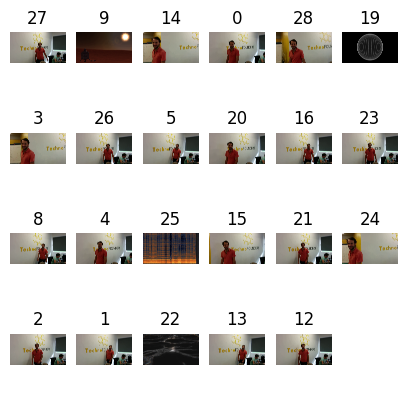

In [10]:
#Affichage de l'échantillon d'images
titles = [
    image_path.stem
    for image_path
    in image_paths[:SAMPLE_SIZE]]
images = [
    cv2.imread(str(image_path))
    for image_path
    in image_paths[:SAMPLE_SIZE]]

sv.plot_images_grid(images=images, titles=titles, grid_size=SAMPLE_GRID_SIZE, size=SAMPLE_PLOT_SIZE)

In [21]:
#création d'un objet tracker
tracker = cv2.TrackerKCF_create()

In [12]:
#caractéristique d'une image quelconque de la video pour initialiser le tracker
height, width, _ = images[0].shape

In [13]:
#définition des coordonnées du bounding box
bbox = (0, 0, width, height)

In [14]:
#initialisation du tracker
tracker.init(images[0], bbox)

In [15]:
#initialisation de l'objet qui contiendra les images trackées
tracked_frames = [(bbox, images[0])]

In [16]:
# Parcours des images
for image in images:
    # mise a jour du tracker
    success, bbox = tracker.update(image)

    if success:
        # Stockage de l'image et de sa position selon le tracker
        tracked_frames.append((bbox, image))

In [20]:
# Ordonnancemenr des images selon le positionnement du tracker
tracked_frames.sort(key=lambda x: np.average(x[0][0]+x[0][1]+x[0][2]+x[0][3]), reverse=True)


# Creation d'une nouvelle video avec les positions definies par le tracker
output_video_path = 'sorted_vi.mp4'
video = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), 3, (width, height))

for _, frame in tracked_frames:
    video.write(frame)

# RLiberation de ressources
video.release()
cv2.destroyAllWindows()
print("done")

done
